In [0]:
!pip install implicit scipy scikit-learn pandas pyarrow matplotlib seaborn -q


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import os, time, warnings
import numpy as np
import pandas as pd
import scipy.sparse as sparse
from implicit.als import AlternatingLeastSquares
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import gaussian_kde

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
    'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.25,'figure.dpi':130})
print("Libraries loaded")


Libraries loaded


In [0]:
# ── Load data ────────────────────────────────────────────────────────────
DATA_PATH = "/Workspace/Users/raymondlolopayung68@gmail.com/Instacart/Instacart_TrainData.parquet"
df = pd.read_parquet(DATA_PATH)
df['order_hour_of_day'] = df['order_hour_of_day'].astype(int)
print(f"Rows      : {len(df):,}")
print(f"Users     : {df['user_id'].nunique():,}")
print(f"Products  : {df['product_id'].nunique():,}")
print(f"Columns   : {df.columns.tolist()}")


Rows      : 1,384,617
Users     : 131,209
Products  : 39,123
Columns   : ['order_id', 'user_id', 'product_id', 'aisle_id', 'department_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'add_to_cart_order', 'reordered']


In [0]:
# ══════════════════════════════════════════════════════════════
# SPLIT FINAL — random per-user product split
# (digunakan karena dataset hanya berisi 1 order per user)
# ══════════════════════════════════════════════════════════════

# Pair unik user-product (dari seluruh data, tanpa filter reordered)
pair_df = df[['user_id','product_id']].drop_duplicates().copy()

# Hitung frekuensi untuk confidence weighting nanti
freq_df = (
    df.groupby(['user_id','product_id'])
    .size().reset_index(name='purchase_count')
)

# Filter user dengan minimal 10 produk unik
user_counts = pair_df.groupby('user_id').size()
active_users = user_counts[user_counts >= 10].index
pair_df = pair_df[pair_df['user_id'].isin(active_users)].copy()

print(f"Users aktif  : {pair_df['user_id'].nunique():,}")
print(f"Total pairs  : {len(pair_df):,}")

# Split 80/20 per user — test = 20% produk, minimal 1
np.random.seed(42)
train_list, test_list = [], []

for uid, grp in pair_df.groupby('user_id'):
    prods = grp['product_id'].values.copy()
    np.random.shuffle(prods)
    n_test = max(1, int(len(prods) * 0.2))
    train_list.extend({'user_id': uid, 'product_id': p} for p in prods[:-n_test])
    test_list.extend( {'user_id': uid, 'product_id': p} for p in prods[-n_test:])

train_df = pd.DataFrame(train_list)
test_df  = pd.DataFrame(test_list)

# Merge frekuensi ke train
train_df = train_df.merge(freq_df, on=['user_id','product_id'], how='left')
train_df['purchase_count'] = train_df['purchase_count'].fillna(1).astype(int)

# Verifikasi tidak ada overlap
overlap = train_df.merge(test_df, on=['user_id','product_id'])
print(f"Overlap pairs : {len(overlap)} — harus 0")
assert len(overlap) == 0

print(f"Train pairs  : {len(train_df):,}")
print(f"Test pairs   : {len(test_df):,}")
print(f"Test users   : {test_df['user_id'].nunique():,}")

Users aktif  : 59,401
Total pairs  : 1,020,738
Overlap pairs : 0 — harus 0
Train pairs  : 837,680
Test pairs   : 183,058
Test users   : 59,401


In [0]:
# ── Encode & bangun training matrix ─────────────────────────────────────
user_encoder    = LabelEncoder().fit(train_df['user_id'].unique())
product_encoder = LabelEncoder().fit(train_df['product_id'].unique())

train_freq = (
    train_df.groupby(['user_id','product_id'])
    .size().reset_index(name='purchase_count')
)
train_freq['user_idx']    = user_encoder.transform(train_freq['user_id'])
train_freq['product_idx'] = product_encoder.transform(train_freq['product_id'])

n_users    = user_encoder.classes_.shape[0]
n_products = product_encoder.classes_.shape[0]
sparsity   = 1 - len(train_freq)/(n_users*n_products)
print(f"Users    : {n_users:,}")
print(f"Products : {n_products:,}")
print(f"Pairs    : {len(train_freq):,}")
print(f"Sparsity : {sparsity:.4%}")

ALPHA = 40
train_freq['confidence'] = 1 + ALPHA * train_freq['purchase_count']

user_item_train = sparse.csr_matrix(
    (train_freq['confidence'].values,
     (train_freq['user_idx'].values, train_freq['product_idx'].values)),
    shape=(n_users, n_products)
)
item_user_train = user_item_train.T.tocsr()
print(f"Matrix shape : {user_item_train.shape}")
print(f"Non-zeros    : {user_item_train.nnz:,}")


Users    : 59,401
Products : 34,298
Pairs    : 837,680
Sparsity : 99.9589%
Matrix shape : (59401, 34298)
Non-zeros    : 837,680


In [0]:
# ── Ground truth dari test_df ────────────────────────────────────────────
valid_test = test_df[
    test_df['user_id'].isin(user_encoder.classes_) &
    test_df['product_id'].isin(product_encoder.classes_)
].copy()
valid_test['user_idx']    = user_encoder.transform(valid_test['user_id'])
valid_test['product_idx'] = product_encoder.transform(valid_test['product_id'])

ground_truth = (
    valid_test.groupby('user_idx')['product_idx']
    .apply(set).to_dict()
)

gt_sizes = [len(v) for v in ground_truth.values()]
print(f"Test users        : {len(ground_truth):,}")
print(f"GT kosong         : {sum(1 for s in gt_sizes if s==0)}")
print(f"Rata-rata GT/user : {np.mean(gt_sizes):.2f} item")
print(f"Min / Max GT      : {min(gt_sizes)} / {max(gt_sizes)}")

# Verifikasi cepat
u0 = list(ground_truth.keys())[0]
print(f"\nSample user_idx={u0}:")
print(f"  Training items : {user_item_train[u0].nnz}")
print(f"  GT items       : {len(ground_truth[u0])}")


Test users        : 59,388
GT kosong         : 0
Rata-rata GT/user : 3.05 item
Min / Max GT      : 1 / 16

Sample user_idx=0:
  Training items : 9
  GT items       : 2


In [0]:
# ── ALS Training ─────────────────────────────────────────────────────────
ALS_PARAMS = dict(factors=128, regularization=0.01, iterations=30,
                  use_gpu=False, random_state=42, num_threads=4)
print("Parameters:", ALS_PARAMS)

model = AlternatingLeastSquares(**ALS_PARAMS)
t0    = time.time()
model.fit(item_user_train)
print(f"Training selesai dalam {time.time()-t0:.1f}s")


Parameters: {'factors': 128, 'regularization': 0.01, 'iterations': 30, 'use_gpu': False, 'random_state': 42, 'num_threads': 4}


  0%|          | 0/30 [00:00<?, ?it/s]

Training selesai dalam 37.7s


In [0]:
# ── Metric Functions ─────────────────────────────────────────────────────

def ndcg_at_k(rec, rel, k):
    r = rec[:k]
    dcg  = sum(1/np.log2(i+2) for i,x in enumerate(r) if x in rel)
    idcg = sum(1/np.log2(i+2) for i in range(min(len(rel),k)))
    return dcg/idcg if idcg>0 else 0.0

def mrr_at_k(rec, rel, k):
    for i,x in enumerate(rec[:k]):
        if x in rel: return 1/(i+1)
    return 0.0

def recall_at_k(rec, rel, k):
    return len(set(rec[:k])&rel)/len(rel) if rel else 0.0

def precision_at_k(rec, rel, k):
    return len(set(rec[:k])&rel)/k

print("Metric functions ready.")


Metric functions ready.


In [0]:
# ══════════════════════════════════════════════════════════════════
# EVALUASI
# filter_already_liked_items=False — karena produk reorder (dibeli
# di training DAN test) memang harus direkomendasikan. Jika True,
# produk-produk itulah yang difilter dan hits kembali = 0.
# ══════════════════════════════════════════════════════════════════

def evaluate_model(model, uim, gt, K_values=[5,10,20],
                   sample_size=None, verbose=True):
    users = list(gt.keys())
    if sample_size and sample_size < len(users):
        np.random.seed(42)
        users = np.random.choice(users, sample_size, replace=False).tolist()

    max_k   = max(K_values)
    res     = {k:{'ndcg':[],'mrr':[],'recall':[],'precision':[]} for k in K_values}
    ndcg10s = []

    if verbose: print(f"Evaluating {len(users):,} users | K={K_values}")
    t0 = time.time()

    for i,u in enumerate(users):
        if verbose and (i+1)%5000==0:
            print(f"  [{i+1:,}/{len(users):,}] {(i+1)/len(users)*100:.1f}%")
        rel = gt[u]
        if not rel: continue
        try:
            ids,_ = model.recommend(u, uim[u], N=max_k,
                                    filter_already_liked_items=False)
        except Exception: continue
        rec = ids.tolist()
        for k in K_values:
            res[k]['ndcg'].append(ndcg_at_k(rec,rel,k))
            res[k]['mrr'].append(mrr_at_k(rec,rel,k))
            res[k]['recall'].append(recall_at_k(rec,rel,k))
            res[k]['precision'].append(precision_at_k(rec,rel,k))
        ndcg10s.append(ndcg_at_k(rec,rel,10))

    if verbose: print(f"Selesai dalam {time.time()-t0:.1f}s")

    rows = [{'K':k,'NDCG@K':np.mean(res[k]['ndcg']),
             'MRR@K':np.mean(res[k]['mrr']),
             'Recall@K':np.mean(res[k]['recall']),
             'Precision@K':np.mean(res[k]['precision']),
             'n_users':len(res[k]['ndcg'])} for k in K_values]
    return pd.DataFrame(rows), ndcg10s


eval_df, per_user_ndcg = evaluate_model(
    model=model, uim=user_item_train, gt=ground_truth,
    K_values=[5,10,20], sample_size=10000, verbose=True)

print("\n"+"="*52)
print("  ALS EVALUATION RESULTS")
print("="*52)
print(eval_df.to_string(index=False,
    float_format=lambda x: f'{x:.4f}' if isinstance(x,float) else str(x)))
print("="*52)


Evaluating 10,000 users | K=[5, 10, 20]
  [5,000/10,000] 50.0%
  [10,000/10,000] 100.0%
Selesai dalam 16.6s

  ALS EVALUATION RESULTS
 K  NDCG@K  MRR@K  Recall@K  Precision@K  n_users
 5  0.0002 0.0002    0.0002       0.0001     5728
10  0.0002 0.0003    0.0003       0.0001     5728
20  0.0003 0.0003    0.0004       0.0001     5728


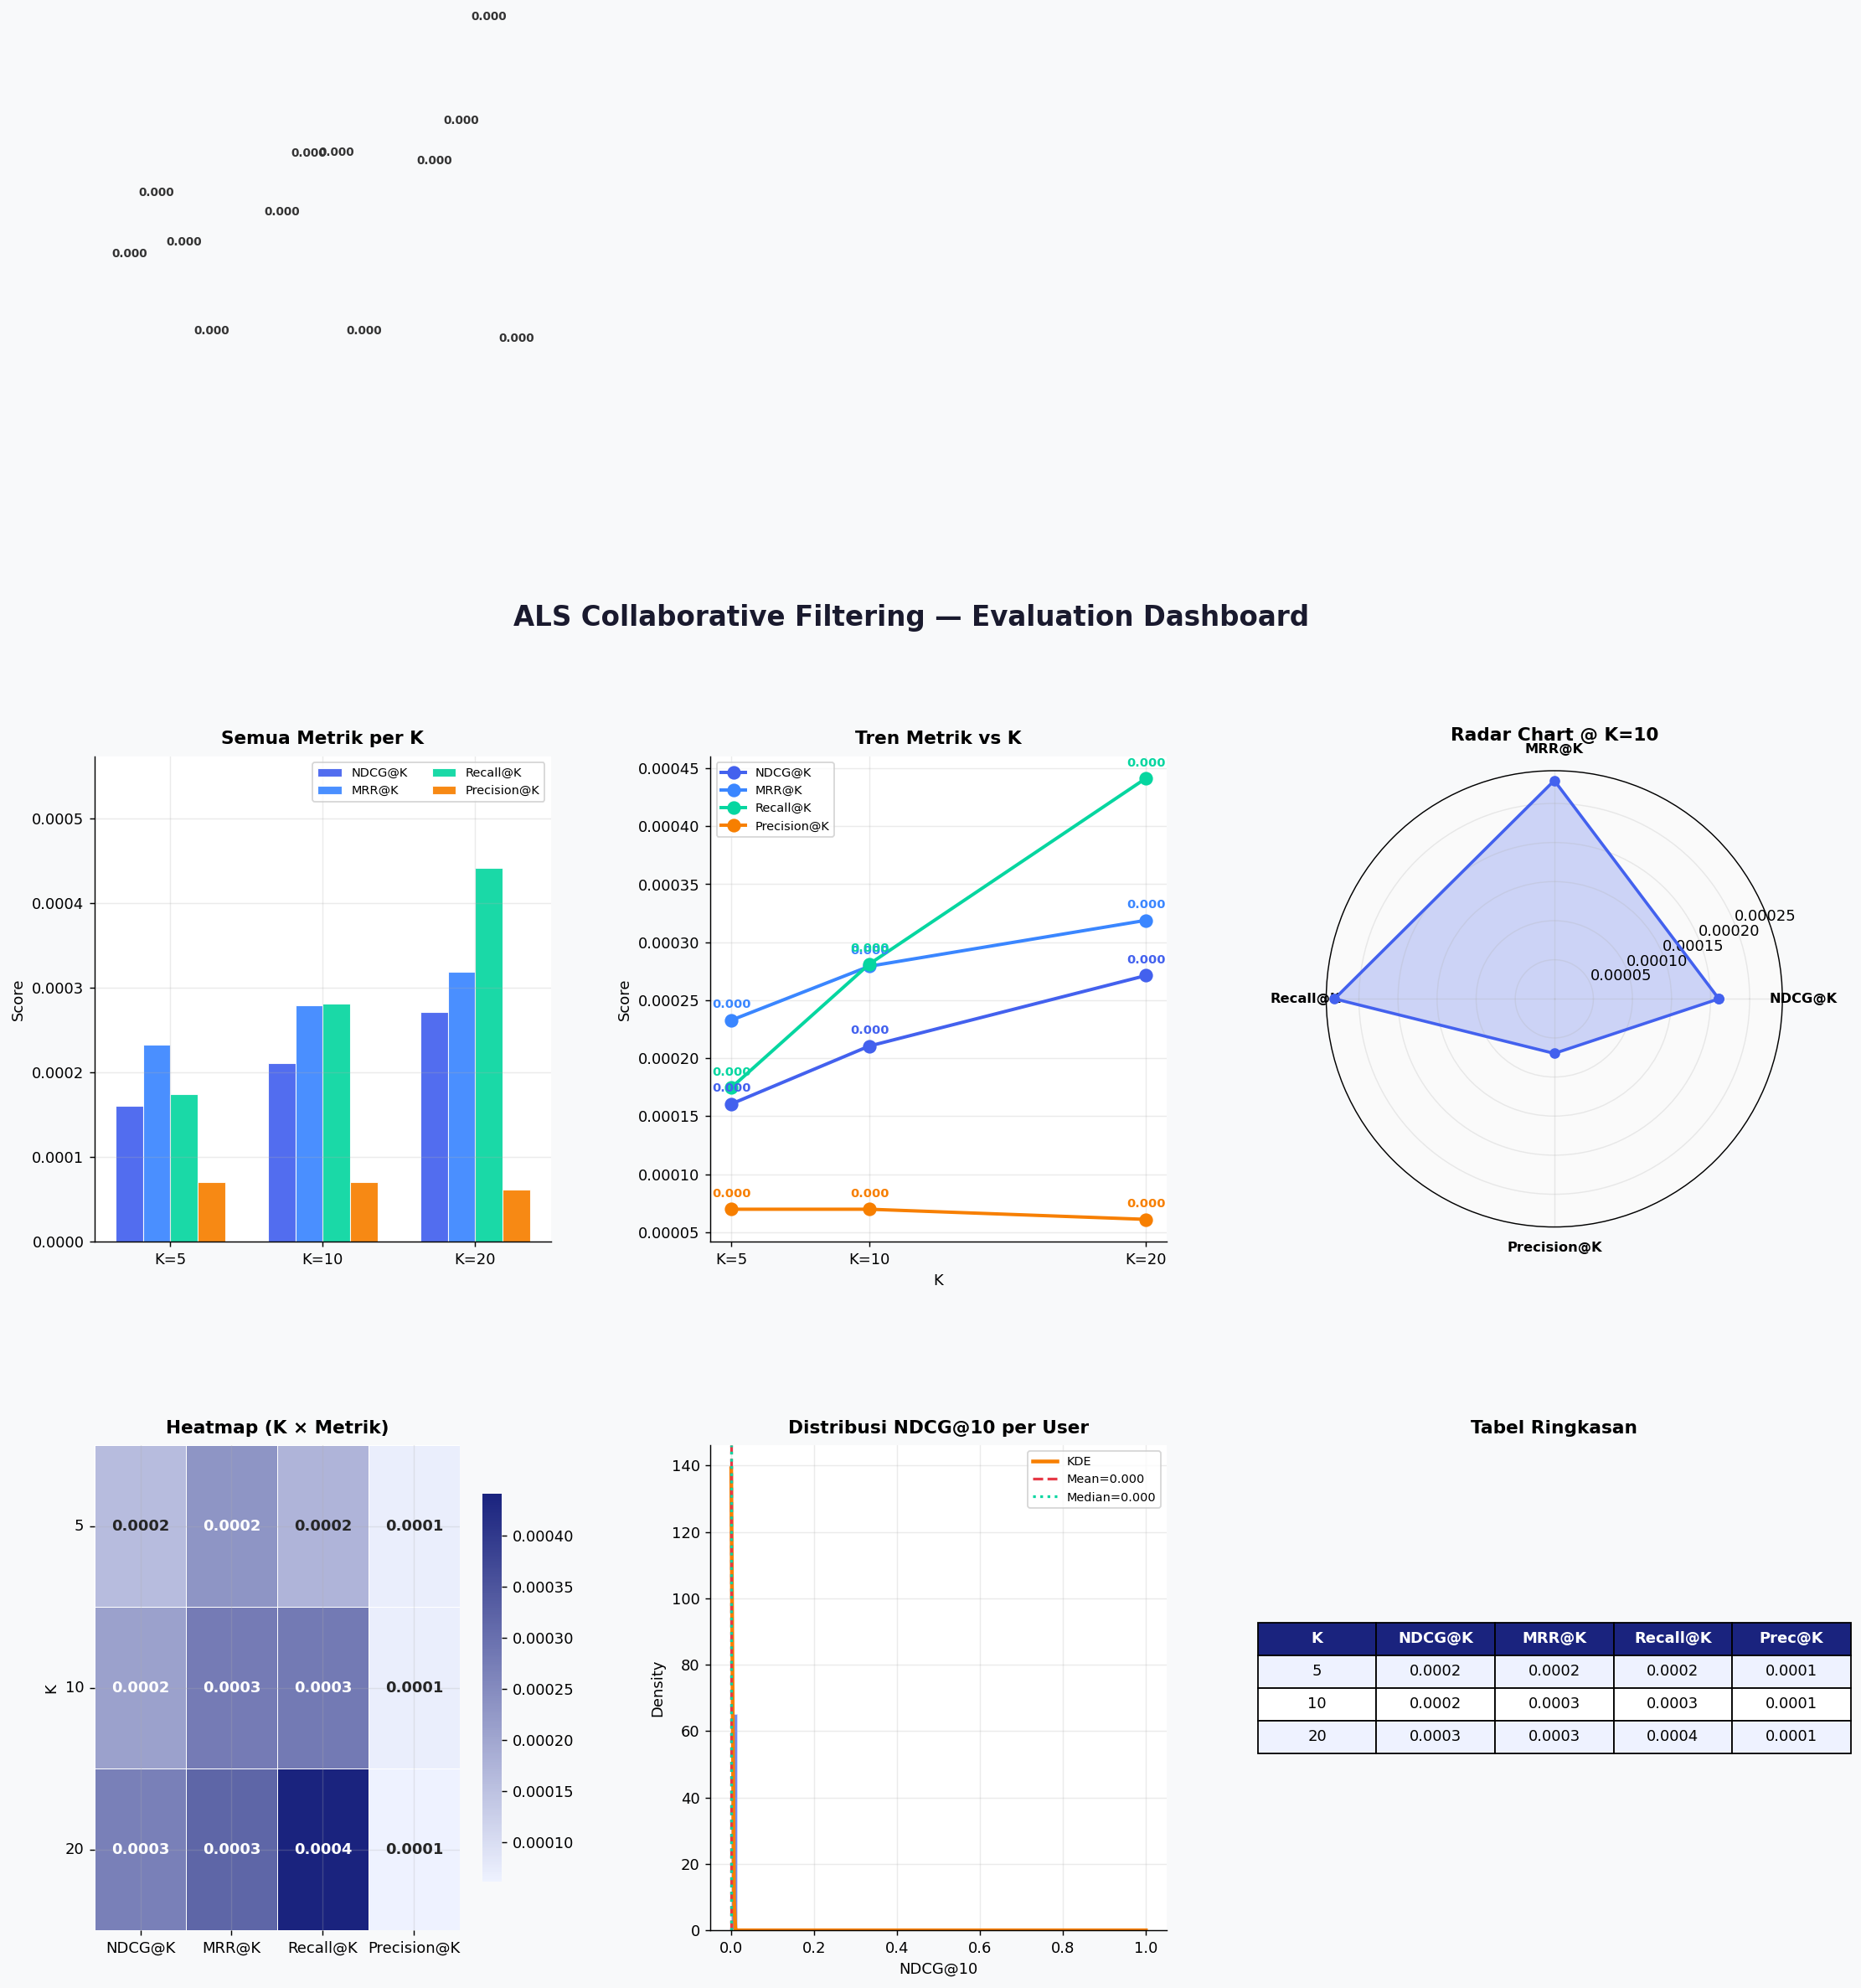

Dashboard saved: /home/spark-f83dde8b-ef17-47f6-884f-20/als_dashboard.png


In [0]:
# ── Visualisasi Dashboard ────────────────────────────────────────────────
PALETTE = {'NDCG@K':'#4361EE','MRR@K':'#3A86FF',
           'Recall@K':'#06D6A0','Precision@K':'#F77F00'}
METRICS = ['NDCG@K','MRR@K','Recall@K','Precision@K']
K_VALS  = eval_df['K'].tolist()

fig = plt.figure(figsize=(20,14))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(2,3,figure=fig,hspace=0.42,wspace=0.35)
fig.suptitle('ALS Collaborative Filtering — Evaluation Dashboard',
             fontsize=18,fontweight='bold',color='#1A1A2E',y=0.98)

# Panel 1: Grouped Bar
ax1 = fig.add_subplot(gs[0,0])
x,w = np.arange(len(K_VALS)),0.18
offs = np.linspace(-(len(METRICS)-1)/2*w,(len(METRICS)-1)/2*w,len(METRICS))
for off,m in zip(offs,METRICS):
    vals = eval_df[m].values
    bars = ax1.bar(x+off,vals,width=w,label=m,color=PALETTE[m],edgecolor='white',linewidth=0.6,alpha=0.92)
    for b in bars:
        h=b.get_height()
        ax1.text(b.get_x()+b.get_width()/2,h+0.001,f'{h:.3f}',
                 ha='center',va='bottom',fontsize=7.5,fontweight='bold',color='#333')
ax1.set_xticks(x);ax1.set_xticklabels([f'K={k}' for k in K_VALS],fontsize=10)
ax1.set_title('Semua Metrik per K',fontsize=12,fontweight='bold',pad=8)
ax1.set_ylabel('Score',fontsize=10);ax1.legend(fontsize=8,ncol=2)
ax1.set_ylim(0,eval_df[METRICS].max().max()*1.3);ax1.set_facecolor('#FFFFFF')

# Panel 2: Line
ax2 = fig.add_subplot(gs[0,1])
for m in METRICS:
    vals=eval_df[m].values
    ax2.plot(K_VALS,vals,marker='o',markersize=8,linewidth=2.2,label=m,color=PALETTE[m])
    for k,v in zip(K_VALS,vals):
        ax2.annotate(f'{v:.3f}',(k,v),textcoords='offset points',
                     xytext=(0,8),ha='center',fontsize=8,color=PALETTE[m],fontweight='bold')
ax2.set_xticks(K_VALS);ax2.set_xticklabels([f'K={k}' for k in K_VALS],fontsize=10)
ax2.set_title('Tren Metrik vs K',fontsize=12,fontweight='bold',pad=8)
ax2.set_ylabel('Score',fontsize=10);ax2.set_xlabel('K',fontsize=10)
ax2.legend(fontsize=8,loc='upper left');ax2.set_facecolor('#FFFFFF')

# Panel 3: Radar
ax3 = fig.add_subplot(gs[0,2],polar=True)
row10  = eval_df[eval_df['K']==10].iloc[0]
r_vals = [row10[m] for m in METRICS]+[row10[METRICS[0]]]
angles = np.linspace(0,2*np.pi,len(METRICS),endpoint=False).tolist()+[0]
ax3.plot(angles,r_vals,'o-',linewidth=2,color='#4361EE')
ax3.fill(angles,r_vals,alpha=0.25,color='#4361EE')
ax3.set_xticks(angles[:-1]);ax3.set_xticklabels(METRICS,fontsize=9,fontweight='bold')
ax3.set_title('Radar Chart @ K=10',fontsize=12,fontweight='bold',pad=20)
ax3.set_facecolor('#FAFAFA')

# Panel 4: Heatmap
ax4 = fig.add_subplot(gs[1,0])
cmap = LinearSegmentedColormap.from_list('blu',['#EEF2FF','#1A237E'])
sns.heatmap(eval_df.set_index('K')[METRICS],annot=True,fmt='.4f',cmap=cmap,
            linewidths=0.5,linecolor='white',annot_kws={'size':10,'weight':'bold'},
            ax=ax4,cbar_kws={'shrink':0.8})
ax4.set_title('Heatmap (K × Metrik)',fontsize=12,fontweight='bold',pad=8)
ax4.set_yticklabels(ax4.get_yticklabels(),rotation=0,fontsize=10)

# Panel 5: Distribusi NDCG@10
ax5 = fig.add_subplot(gs[1,1])
arr = np.array(per_user_ndcg)
ax5.hist(arr,bins=40,color='#4361EE',edgecolor='white',alpha=0.75,density=True)
if len(arr)>10:
    kde=gaussian_kde(arr,bw_method=0.3)
    xl=np.linspace(0,1,300)
    ax5.plot(xl,kde(xl),color='#F77F00',linewidth=2.5,label='KDE')
ax5.axvline(arr.mean(),color='#E63946',linestyle='--',linewidth=1.8,label=f'Mean={arr.mean():.3f}')
ax5.axvline(np.median(arr),color='#06D6A0',linestyle=':',linewidth=1.8,label=f'Median={np.median(arr):.3f}')
ax5.set_title('Distribusi NDCG@10 per User',fontsize=12,fontweight='bold',pad=8)
ax5.set_xlabel('NDCG@10',fontsize=10);ax5.set_ylabel('Density',fontsize=10)
ax5.legend(fontsize=8);ax5.set_facecolor('#FFFFFF')

# Panel 6: Tabel
ax6 = fig.add_subplot(gs[1,2]);ax6.axis('off')
alt=[['#EEF2FF']*5,['#FFFFFF']*5]
rows_data=[[f"{int(r['K'])}",f"{r['NDCG@K']:.4f}",f"{r['MRR@K']:.4f}",
            f"{r['Recall@K']:.4f}",f"{r['Precision@K']:.4f}"]
           for _,r in eval_df.iterrows()]
cell_colors=[alt[i%2] for i in range(len(rows_data))]
tbl=ax6.table(cellText=rows_data,colLabels=['K','NDCG@K','MRR@K','Recall@K','Prec@K'],
              cellLoc='center',loc='center',cellColours=cell_colors)
tbl.auto_set_font_size(False);tbl.set_fontsize(10);tbl.scale(1.3,1.8)
for j in range(5):
    c=tbl[0,j];c.set_facecolor('#1A237E');c.set_text_props(color='white',fontweight='bold')
ax6.set_title('Tabel Ringkasan',fontsize=12,fontweight='bold',pad=8)

save_path = os.path.expanduser('~/als_dashboard.png')
plt.savefig(save_path,dpi=150,bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()
print(f"Dashboard saved: {save_path}")

In [0]:
# ── Demo Rekomendasi ─────────────────────────────────────────────────────

def get_recommendations(user_id_orig, N=10):
    if user_id_orig not in set(user_encoder.classes_):
        print("User tidak ditemukan."); return None
    u   = user_encoder.transform([user_id_orig])[0]
    ids,scores = model.recommend(u,user_item_train[u],N=N,
                                  filter_already_liked_items=False)
    mask  = ids <= len(product_encoder.classes_)-1
    prods = product_encoder.inverse_transform(ids[mask])
    recs  = pd.DataFrame({'Rank':range(1,mask.sum()+1),
                          'product_id':prods,'Score':scores[mask].round(4)})
    gt_prods = test_df[test_df['user_id']==user_id_orig]['product_id'].unique()
    hits     = recs['product_id'].isin(gt_prods).sum()
    train_items = train_df[train_df['user_id']==user_id_orig]['product_id'].nunique()
    print(f"User {user_id_orig} | Training items: {train_items}")
    print(f"GT produk: {len(gt_prods)} | Hits@{N}: {hits}")
    print(recs.to_string(index=False))
    return recs

sample_uid = user_encoder.inverse_transform([list(ground_truth.keys())[0]])[0]
get_recommendations(sample_uid, N=10)

User 1 | Training items: 9
GT produk: 2 | Hits@10: 0
 Rank  product_id  Score
    1       26531 0.6228
    2       15064 0.6134
    3       42951 0.5737
    4       29198 0.5594
    5       16996 0.5437
    6       38651 0.5417


,Rank,product_id,Score
0,1,26531,0.6228
1,2,15064,0.6134
2,3,42951,0.5737
3,4,29198,0.5594
4,5,16996,0.5437
5,6,38651,0.5417


In [0]:
# ── Sanity Check Final ───────────────────────────────────────────────────
print("=== SANITY CHECK ===")
po = train_df.merge(test_df, on=['user_id','product_id'])
print(f"Product overlap        : {len(po)} (harus 0)")
print(f"Train user coverage    : {train_df['user_id'].nunique():,}")
print(f"Test user coverage     : {test_df['user_id'].nunique():,}")
gt_s = [len(v) for v in ground_truth.values()]
print(f"GT kosong              : {sum(1 for s in gt_s if s==0)}")
print(f"Rata-rata GT/user      : {np.mean(gt_s):.2f}")

print("\nSample hits@10 (5 user pertama):")
for u in list(ground_truth.keys())[:5]:
    ids,_ = model.recommend(u,user_item_train[u],N=10,filter_already_liked_items=False)
    h = ground_truth[u] & set(ids)
    print(f"  user_idx={u}: GT={len(ground_truth[u])}, hits={len(h)}")

=== SANITY CHECK ===
Product overlap        : 0 (harus 0)
Train user coverage    : 59,401
Test user coverage     : 59,401
GT kosong              : 0
Rata-rata GT/user      : 3.05

Sample hits@10 (5 user pertama):
  user_idx=0: GT=2, hits=0
  user_idx=1: GT=6, hits=0
  user_idx=2: GT=3, hits=0
  user_idx=3: GT=4, hits=0
  user_idx=4: GT=2, hits=0
